# Trabalho 07 — Imagem RGB: conversão por média
## Da imagem colorida à escala de cinza

**Disciplina:** Computação Gráfica / Processamento de Imagens Digitais
**Professor:** André Alessandro Stein
**Aluno:** Igor
**Instituição:** IFC — Campus Rio do Sul

### Enunciado

> **a)** Aplicar cálculo da média entre os valores RGB do arquivo `Fig4.ppm`
> (tipo P3) e gerar imagem de saída em escala de cinza (**P2**) para cada píxel
> da imagem.
>
> **b)** Aplicar cálculo da média entre os valores RGB do arquivo `Fig4.ppm`
> (tipo P3) e gerar imagem de saída com a média dos valores RGB em cada píxel.
> Saída tipo **P3**.

### A relação entre os dois itens

O cálculo é o mesmo nos dois casos — muda apenas onde o resultado é gravado:

| | Item (a) | Item (b) |
|---|---|---|
| Formato de saída | PGM P2 | PPM P3 |
| Valores por píxel | 1 | 3 |
| Conteúdo | a média | a média, replicada em R, G e B |
| Informação carregada | idêntica | idêntica |

O item (b) produz uma imagem que **é colorida em formato mas acromática em
conteúdo**: como `R = G = B` em todo píxel, nenhuma cor é representada. Uma das
verificações do notebook confirma essa equivalência numericamente.

### Referências

- STEIN, A. A.; HECK, C. *Processamento de Imagens Digitais* — slides da disciplina.
- LOPES, J. M. Brisson. *Formatos de Imagem*. DEI — IST, Lisboa, 2003 (reed. 2013).

## 1. Fundamentação

### O modelo RGB

Os slides da disciplina partem da fisiologia: a retina possui células
fotorreceptoras divididas em bastonetes, sensíveis à luminosidade, e cones,
sensíveis à cor em três faixas — vermelho, verde e azul. O modelo RGB é a
transposição direta dessa estrutura: toda cor é descrita como combinação
variável em proporção dessas três componentes.

Os comprimentos de onda de referência citados no material são 700,0 nm para o
vermelho, 546,1 nm para o verde e 435,8 nm para o azul. Combinadas duas a duas
em igual intensidade, produzem as secundárias — amarelo, magenta e ciano.

### PPM P3 e PGM P2

Ambos pertencem à família PBM e compartilham a estrutura de cabeçalho. A
diferença está na quantidade de valores por píxel:

| Formato | Magic | Valores por píxel | Conteúdo |
|---------|-------|-------------------|----------|
| PPM | P3 | 3 | componentes R, G e B |
| PGM | P2 | 1 | intensidade luminosa |

Como registra a apostila, o número total de valores é `altura × largura` para o
PGM e **três vezes esse número** para o PPM, "uma vez que cada píxel é
representado pelas três componentes RGB da respectiva cor".

Nos dois casos o varrimento é linha a linha, de cima para baixo, e da esquerda
para a direita dentro de cada linha. No PPM, as três componentes de um mesmo
píxel aparecem consecutivas, na ordem R, G, B.

### A conversão por média

    cinza(x, y) = [ R(x, y) + G(x, y) + B(x, y) ] / 3

É uma transformação pontual, mas de natureza diferente das anteriores: em vez de
mapear um valor em outro, ela **reduz a dimensionalidade** de cada píxel — de um
vetor de três componentes para um escalar.

A perda é substancial e irreversível. Três valores independentes viram um só:
qualquer trio que some o mesmo total produz idêntico cinza. Vermelho puro
(255, 0, 0), verde puro (0, 255, 0) e o cinza (85, 85, 85) resultam todos em 85 —
tornam-se indistinguíveis.

### Arredondamento

A média de três inteiros raramente é inteira. Como o PGM só admite inteiros, é
preciso decidir entre truncar e arredondar. Adoto **arredondamento ao mais
próximo**, pela mesma razão da Atividade 4: o truncamento erra sempre para baixo
e introduz viés de escurecimento, enquanto o arredondamento distribui o erro
simetricamente.

In [9]:
# Bibliotecas e configuração

import textwrap
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

BASE = Path.cwd()
ENTRADA = BASE / "entrada"
SAIDA = BASE / "saida"
SAIDA.mkdir(exist_ok=True)

# Troque para "Fig1.ppm" para processar a outra imagem
NOME_IMAGEM = "Fig4.ppm"
ARQUIVO_ENTRADA = ENTRADA / NOME_IMAGEM

LIMITE_COLUNA = 70      # limite das variantes ASCII (spec PBM)

print(f"Entrada existe : {ARQUIVO_ENTRADA.exists()}")
print(f"Arquivo        : {ARQUIVO_ENTRADA.name}")

Entrada existe : True
Arquivo        : Fig4.ppm


In [10]:
# --- Leitores e escritores PBM/PGM/PPM ---

def _fluxo_tokens(arquivo):
    """Gera tokens do arquivo, descartando comentários iniciados por '#'."""
    for linha in arquivo:
        util = linha.split("#", 1)[0]
        for token in util.split():
            yield token


def ler_ppm_p3(caminho):
    """Lê um PPM tipo P3 e devolve (matriz (altura, largura, 3), maxval)."""
    with open(caminho, "r", encoding="ascii") as f:
        it = _fluxo_tokens(f)

        magic = next(it)
        if magic != "P3":
            raise ValueError(f"Magic number inesperado: {magic!r} (esperado 'P3')")

        largura, altura, maxval = (int(next(it)) for _ in range(3))
        esperados = largura * altura * 3
        dados = np.fromiter(map(int, it), dtype=np.int32, count=esperados)

    if dados.size != esperados:
        raise ValueError(f"Esperados {esperados} valores, lidos {dados.size}")

    return dados.reshape(altura, largura, 3), maxval


def ler_pgm_p2(caminho):
    """Lê um PGM tipo P2 e devolve (matriz 2D, maxval)."""
    with open(caminho, "r", encoding="ascii") as f:
        it = _fluxo_tokens(f)

        magic = next(it)
        if magic != "P2":
            raise ValueError(f"Magic number inesperado: {magic!r} (esperado 'P2')")

        largura, altura, maxval = (int(next(it)) for _ in range(3))
        dados = np.fromiter(map(int, it), dtype=np.int32, count=largura * altura)

    return dados.reshape(altura, largura), maxval

In [11]:
# --- Escritores ---

def _escrever_pnm(caminho, magic, plano, largura, altura, maxval,
                  comentario, valores_por_linha, limite_coluna):
    """Rotina comum de gravação para P2 e P3."""
    with open(caminho, "w", encoding="ascii", newline="\n") as f:
        f.write(f"{magic}\n")
        if comentario:
            for trecho in textwrap.wrap(comentario, width=limite_coluna - 2):
                f.write(f"# {trecho}\n")
        f.write(f"{largura} {altura}\n")
        f.write(f"{maxval}\n")

        n = valores_por_linha
        linhas = [" ".join(map(str, plano[i:i + n]))
                  for i in range(0, len(plano), n)]
        f.write("\n".join(linhas))
        f.write("\n")

    return caminho


def escrever_pgm_p2(caminho, imagem, maxval, comentario=None,
                    limite_coluna=LIMITE_COLUNA):
    """Grava uma matriz 2D como PGM tipo P2."""
    imagem = np.asarray(imagem)
    if imagem.ndim != 2:
        raise ValueError(f"Esperada matriz 2D, recebido shape {imagem.shape}")
    if imagem.min() < 0 or imagem.max() > maxval:
        raise ValueError(f"Valores fora do intervalo [0, {maxval}]")

    altura, largura = imagem.shape
    n = max(1, (limite_coluna + 1) // (len(str(maxval)) + 1))

    return _escrever_pnm(caminho, "P2", imagem.reshape(-1).tolist(),
                         largura, altura, maxval, comentario, n, limite_coluna)


def escrever_ppm_p3(caminho, imagem, maxval, comentario=None,
                    limite_coluna=LIMITE_COLUNA):
    """Grava uma matriz (altura, largura, 3) como PPM tipo P3."""
    imagem = np.asarray(imagem)
    if imagem.ndim != 3 or imagem.shape[2] != 3:
        raise ValueError(f"Esperado shape (altura, largura, 3), recebido {imagem.shape}")
    if imagem.min() < 0 or imagem.max() > maxval:
        raise ValueError(f"Valores fora do intervalo [0, {maxval}]")

    altura, largura, _ = imagem.shape

    # Arredonda para múltiplo de 3 para manter píxeis RGB inteiros por linha
    n = max(1, (limite_coluna + 1) // (len(str(maxval)) + 1))
    n = max(3, n - (n % 3))

    return _escrever_pnm(caminho, "P3", imagem.reshape(-1).tolist(),
                         largura, altura, maxval, comentario, n, limite_coluna)


def verificar_limite_colunas(caminho, limite=LIMITE_COLUNA):
    maior = 0
    with open(caminho, "r", encoding="ascii") as f:
        for numero, linha in enumerate(f, start=1):
            comprimento = len(linha.rstrip("\n"))
            if comprimento > limite:
                raise AssertionError(f"Linha {numero}: {comprimento} caracteres")
            maior = max(maior, comprimento)
    return maior

In [12]:
# --- Leitura e caracterização da entrada ---

rgb, MAXVAL = ler_ppm_p3(ARQUIVO_ENTRADA)
altura, largura, _ = rgb.shape

print("IMAGEM DE ENTRADA")
print("-" * 54)
print(f"Arquivo          : {ARQUIVO_ENTRADA.name}")
print(f"Dimensões        : {largura} x {altura}")
print(f"Total de píxeis  : {largura * altura:,}")
print(f"Valores no arquivo: {rgb.size:,}  ({largura * altura:,} x 3)")
print(f"maxval           : {MAXVAL}")
print(f"Tamanho em disco : {ARQUIVO_ENTRADA.stat().st_size / 1024**2:.2f} MB")
print()
print(f"{'Canal':<10}{'Mín':>6}{'Máx':>6}{'Média':>10}{'Desvio':>10}")
print("-" * 42)
for i, nome in enumerate(("Vermelho", "Verde", "Azul")):
    c = rgb[:, :, i]
    print(f"{nome:<10}{c.min():>6}{c.max():>6}{c.mean():>10.2f}{c.std():>10.2f}")

cores_distintas = len(np.unique(rgb.reshape(-1, 3), axis=0))
print()
print(f"Cores distintas  : {cores_distintas:,} de "
      f"{(MAXVAL + 1) ** 3:,} possíveis")

IMAGEM DE ENTRADA
------------------------------------------------------
Arquivo          : Fig4.ppm
Dimensões        : 481 x 321
Total de píxeis  : 154,401
Valores no arquivo: 463,203  (154,401 x 3)
maxval           : 255
Tamanho em disco : 1.49 MB

Canal        Mín   Máx     Média    Desvio
------------------------------------------
Vermelho       1   255     87.56     59.23
Verde         19   213     83.64     34.78
Azul           0   235     83.91     52.24

Cores distintas  : 82,005 de 16,777,216 possíveis


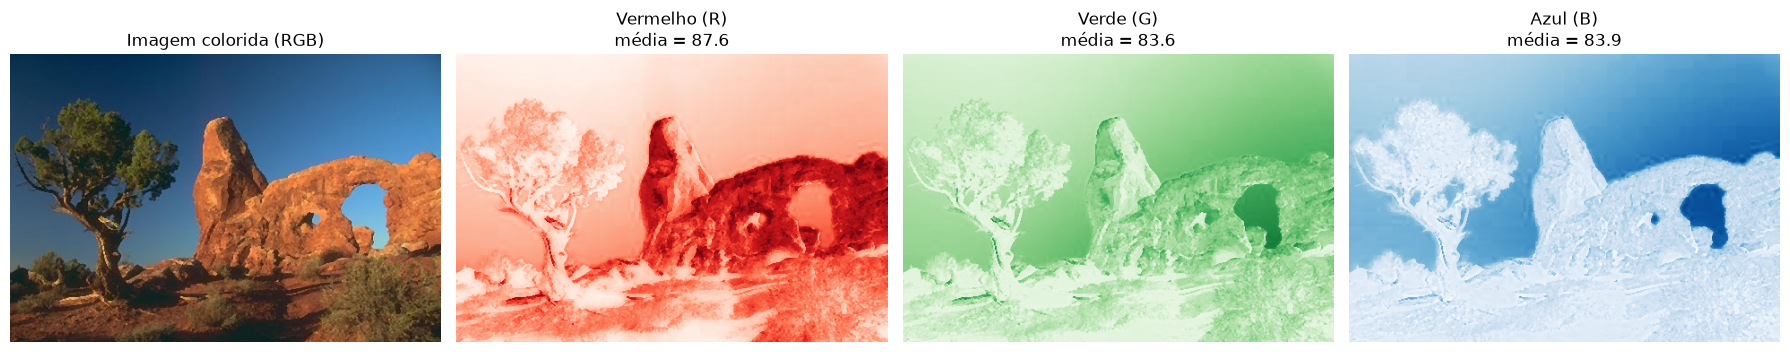

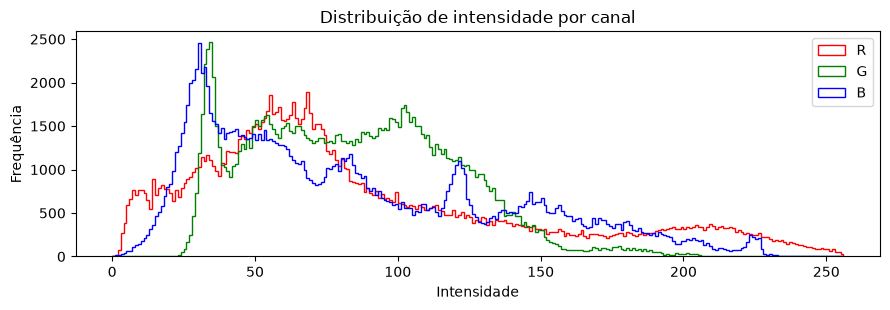

In [13]:
# --- Decomposição nos três canais ---

fig, eixos = plt.subplots(1, 4, figsize=(18, 4.5))

eixos[0].imshow(rgb / MAXVAL)
eixos[0].set_title("Imagem colorida (RGB)")

for i, (nome, mapa) in enumerate(zip(("Vermelho (R)", "Verde (G)", "Azul (B)"),
                                     ("Reds", "Greens", "Blues"))):
    eixos[i + 1].imshow(rgb[:, :, i], cmap=mapa, vmin=0, vmax=MAXVAL)
    eixos[i + 1].set_title(f"{nome}\nmédia = {rgb[:, :, i].mean():.1f}")

for ax in eixos:
    ax.axis("off")
plt.tight_layout()
plt.show()

# Histogramas dos três canais sobrepostos
fig, ax = plt.subplots(figsize=(9, 3.2))
for i, (cor, nome) in enumerate(zip(("red", "green", "blue"), ("R", "G", "B"))):
    ax.hist(rgb[:, :, i].ravel(), bins=MAXVAL + 1, range=(0, MAXVAL + 1),
            histtype="step", color=cor, label=nome)
ax.set_title("Distribuição de intensidade por canal")
ax.set_xlabel("Intensidade")
ax.set_ylabel("Frequência")
ax.legend()
plt.tight_layout()
plt.show()

---

## Item (a) — Média dos canais, saída em PGM P2

Para cada píxel:

    cinza = round( (R + G + B) / 3 )

### Cuidado com o tipo de dado

A soma `R + G + B` pode chegar a 765, valor que **estoura um inteiro de 8 bits**.
Se o array estivesse em `uint8`, a soma sofreria wraparound silencioso e
produziria resultados absurdos, sem qualquer mensagem de erro.

Duas defesas possíveis: converter para ponto flutuante antes de somar, ou usar
`np.mean` sobre o eixo dos canais — que já promove o tipo internamente. Uso a
segunda, e a célula seguinte demonstra explicitamente o que aconteceria sem esse
cuidado, porque é um erro que passa despercebido com facilidade.

In [14]:
# --- Demonstração do risco de overflow ---

exemplo = np.array([200, 210, 220], dtype=np.uint8)

soma_insegura = exemplo[0] + exemplo[1] + exemplo[2]   # aritmética uint8
soma_segura = exemplo.astype(np.int32).sum()

print("Píxel de exemplo (uint8):", exemplo.tolist())
print(f"Soma correta            : {soma_segura}")
print(f"Soma em uint8           : {soma_insegura}  <-- wraparound")
print()
print(f"Média correta           : {soma_segura / 3:.2f}")
print(f"Média a partir do erro  : {soma_insegura / 3:.2f}")
print()

# O caso realmente perigoso: operação vetorizada sobre um array inteiro.
# Aqui o NumPy NÃO emite aviso — o wraparound é totalmente silencioso.
bloco = np.full((4, 4, 3), [200, 210, 220], dtype=np.uint8)

soma_vet = bloco[:, :, 0] + bloco[:, :, 1] + bloco[:, :, 2]
soma_ok = bloco.astype(np.int32).sum(axis=2)

print(f"Bloco 4x4 de píxeis {bloco[0, 0].tolist()}:")
print(f"  soma vetorizada em uint8 : {soma_vet[0, 0]}  (dtype {soma_vet.dtype})")
print(f"  soma correta             : {soma_ok[0, 0]}")
print(f"  divergência              : {int(soma_ok[0, 0] - soma_vet[0, 0])}")
print()
print("Na operação entre escalares o NumPy emite um RuntimeWarning. Já na")
print("operação vetorizada — que é a forma como o cálculo seria realmente")
print("escrito — nenhum aviso é gerado: o resultado errado simplesmente")
print("segue adiante. Daí a importância de promover o tipo antes de somar.")

Píxel de exemplo (uint8): [200, 210, 220]
Soma correta            : 630
Soma em uint8           : 118  <-- wraparound

Média correta           : 210.00
Média a partir do erro  : 39.33

Bloco 4x4 de píxeis [200, 210, 220]:
  soma vetorizada em uint8 : 118  (dtype uint8)
  soma correta             : 630
  divergência              : 512

Na operação entre escalares o NumPy emite um RuntimeWarning. Já na
operação vetorizada — que é a forma como o cálculo seria realmente
escrito — nenhum aviso é gerado: o resultado errado simplesmente
segue adiante. Daí a importância de promover o tipo antes de somar.


/tmp/ipykernel_29323/3056039072.py:5: RuntimeWarning: overflow encountered in scalar add
  soma_insegura = exemplo[0] + exemplo[1] + exemplo[2]   # aritmética uint8


In [15]:
# --- Item (a): cálculo da média ---

def media_rgb(imagem_rgb):
    """
    Calcula a média aritmética dos três canais de cada píxel.

    np.mean promove o tipo internamente, evitando overflow na soma. O
    arredondamento ao mais próximo evita o viés de escurecimento que o
    truncamento introduziria.
    """
    media = imagem_rgb.mean(axis=2)                     # média exata (float)
    return np.rint(media).astype(np.int32)              # arredondada


cinza = media_rgb(rgb)

# Verificação independente, com aritmética explícita
soma = rgb[:, :, 0].astype(np.int64) + rgb[:, :, 1] + rgb[:, :, 2]
conferencia = np.rint(soma / 3).astype(np.int32)
assert np.array_equal(cinza, conferencia), "Divergência entre os dois cálculos!"
print("Cálculo por np.mean e por soma explícita coincidem.\n")

assert cinza.min() >= 0 and cinza.max() <= MAXVAL
print(f"Shape da saída   : {cinza.shape}  (2D — um valor por píxel)")
print(f"Mínimo / Máximo  : {cinza.min()} / {cinza.max()}")
print(f"Média            : {cinza.mean():.2f}")
print(f"Níveis distintos : {np.unique(cinza).size} de {MAXVAL + 1}")
print()
print(f"Redução de dados : {rgb.size:,} valores -> {cinza.size:,} valores "
      f"(1/3 do original)")

Cálculo por np.mean e por soma explícita coincidem.

Shape da saída   : (321, 481)  (2D — um valor por píxel)
Mínimo / Máximo  : 18 / 203
Média            : 85.04
Níveis distintos : 185 de 256

Redução de dados : 463,203 valores -> 154,401 valores (1/3 do original)


In [16]:
# --- Item (a): gravação e validação ---

ARQUIVO_A = SAIDA / f"a_{ARQUIVO_ENTRADA.stem}_media_P2.pgm"

escrever_pgm_p2(
    ARQUIVO_A, cinza, MAXVAL,
    comentario=(f"item (a) - escala de cinza pela media aritmetica dos canais "
                f"RGB - origem {ARQUIVO_ENTRADA.name}")
)

lida_a, maxval_a = ler_pgm_p2(ARQUIVO_A)
assert maxval_a == MAXVAL
assert np.array_equal(lida_a, cinza)

print(f"Arquivo gravado : {ARQUIVO_A.name}")
print(f"Magic number    : P2")
print(f"maxval          : {maxval_a}")
print(f"Round-trip      : OK")
print(f"Maior linha     : {verificar_limite_colunas(ARQUIVO_A)} caracteres")
print(f"Tamanho         : {ARQUIVO_A.stat().st_size / 1024**2:.2f} MB")
print()
print("Primeiras linhas:")
print("-" * 50)
with open(ARQUIVO_A) as f:
    for _ in range(6):
        print(f.readline().rstrip())

Arquivo gravado : a_Fig4_media_P2.pgm
Magic number    : P2
maxval          : 255
Round-trip      : OK
Maior linha     : 67 caracteres
Tamanho         : 0.49 MB

Primeiras linhas:
--------------------------------------------------
P2
# item (a) - escala de cinza pela media aritmetica dos canais RGB -
# origem Fig4.ppm
481 321
255
39 39 39 39 39 39 39 39 40 40 40 41 41 42 42 42 42


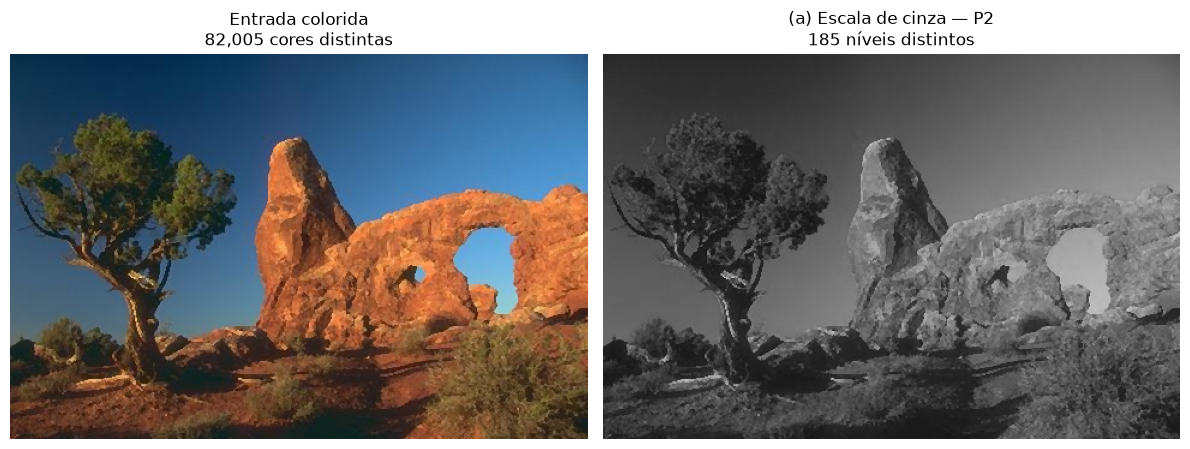

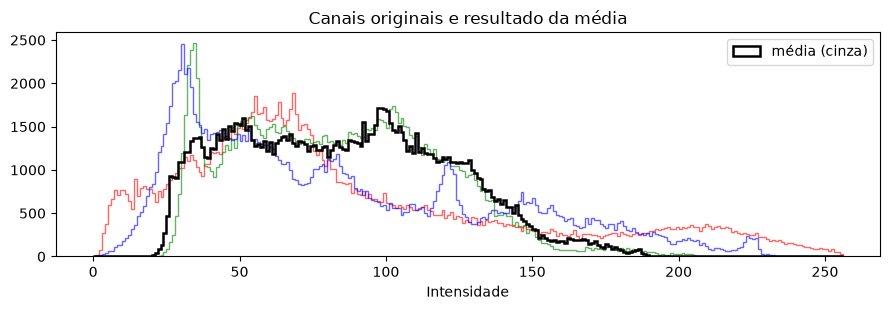

O histograma da média é mais concentrado que o dos canais individuais:
promediar três valores atenua os extremos, efeito análogo ao de uma
filtragem — a variância do resultado é menor que a de cada canal.


In [17]:
# --- Item (a): comparação visual ---

fig, eixos = plt.subplots(1, 2, figsize=(12, 5))

eixos[0].imshow(rgb / MAXVAL)
eixos[0].set_title(f"Entrada colorida\n{cores_distintas:,} cores distintas")

eixos[1].imshow(cinza, cmap="gray", vmin=0, vmax=MAXVAL)
eixos[1].set_title(f"(a) Escala de cinza — P2\n{np.unique(cinza).size} níveis distintos")

for ax in eixos:
    ax.axis("off")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 3.2))
for i, cor in enumerate(("red", "green", "blue")):
    ax.hist(rgb[:, :, i].ravel(), bins=MAXVAL + 1, range=(0, MAXVAL + 1),
            histtype="step", color=cor, alpha=0.6)
ax.hist(cinza.ravel(), bins=MAXVAL + 1, range=(0, MAXVAL + 1),
        histtype="step", color="black", linewidth=1.8, label="média (cinza)")
ax.set_title("Canais originais e resultado da média")
ax.set_xlabel("Intensidade")
ax.legend()
plt.tight_layout()
plt.show()

print("O histograma da média é mais concentrado que o dos canais individuais:")
print("promediar três valores atenua os extremos, efeito análogo ao de uma")
print("filtragem — a variância do resultado é menor que a de cada canal.")

---

## Item (b) — Mesma média, saída em PPM P3

Aqui o valor calculado é o mesmo do item (a). O que muda é a gravação: em vez de
um valor por píxel, os três canais recebem **o mesmo** valor.

    R(x, y) = G(x, y) = B(x, y) = cinza(x, y)

### Por que isso produz cinza

No modelo RGB, uma cor é acromática exatamente quando as três componentes são
iguais. Percorrendo essa condição de (0,0,0) a (255,255,255) obtém-se a
**diagonal do cubo RGB** — o eixo dos cinzas.

Ao forçar `R = G = B`, o item (b) projeta todas as cores da imagem sobre essa
diagonal. O arquivo continua sendo um PPM legítimo, com capacidade para
16.777.216 cores, mas usa apenas as 256 que estão sobre o eixo acromático.

### A relação entre os dois arquivos

Os itens (a) e (b) carregam informação idêntica. O item (b) simplesmente repete
cada valor três vezes, ocupando cerca do triplo do espaço sem acrescentar nada.
A célula de validação confirma isso comparando os dois arquivos lidos do disco.

In [18]:
# --- Item (b): replicar a média nos três canais ---

def cinza_para_rgb(cinza):
    """
    Constrói uma imagem RGB em que os três canais recebem o mesmo valor.

    np.stack no eixo 2 monta (altura, largura, 3) a partir de três cópias da
    matriz 2D — resultado equivalente ao de np.repeat, porém mais explícito
    quanto à intenção.
    """
    return np.stack([cinza, cinza, cinza], axis=2)


cinza_rgb = cinza_para_rgb(cinza)

print(f"Shape do item (a): {cinza.shape}      (2D)")
print(f"Shape do item (b): {cinza_rgb.shape}  (3D)")
print()

# Os três canais devem ser idênticos entre si
assert np.array_equal(cinza_rgb[:, :, 0], cinza_rgb[:, :, 1])
assert np.array_equal(cinza_rgb[:, :, 1], cinza_rgb[:, :, 2])
print("Os três canais são idênticos entre si — imagem acromática.")

# Toda cor presente está sobre a diagonal do cubo RGB
cores = np.unique(cinza_rgb.reshape(-1, 3), axis=0)
na_diagonal = np.all(cores == cores[:, [0]], axis=1).all()
assert na_diagonal
print(f"Todas as {len(cores)} cores presentes estão sobre a diagonal R=G=B.")
print()
print(f"Cores distintas na entrada : {cores_distintas:,}")
print(f"Cores distintas no item (b): {len(cores):,}")
print(f"Redução                    : "
      f"{(1 - len(cores) / cores_distintas) * 100:.2f}%")

Shape do item (a): (321, 481)      (2D)
Shape do item (b): (321, 481, 3)  (3D)

Os três canais são idênticos entre si — imagem acromática.
Todas as 185 cores presentes estão sobre a diagonal R=G=B.

Cores distintas na entrada : 82,005
Cores distintas no item (b): 185
Redução                    : 99.77%


In [19]:
# --- Item (b): gravação e validação ---

ARQUIVO_B = SAIDA / f"b_{ARQUIVO_ENTRADA.stem}_media_P3.ppm"

escrever_ppm_p3(
    ARQUIVO_B, cinza_rgb, MAXVAL,
    comentario=(f"item (b) - media dos canais RGB replicada nas tres "
                f"componentes - origem {ARQUIVO_ENTRADA.name}")
)

lida_b, maxval_b = ler_ppm_p3(ARQUIVO_B)
assert maxval_b == MAXVAL
assert np.array_equal(lida_b, cinza_rgb)

print(f"Arquivo gravado : {ARQUIVO_B.name}")
print(f"Magic number    : P3")
print(f"maxval          : {maxval_b}")
print(f"Round-trip      : OK")
print(f"Maior linha     : {verificar_limite_colunas(ARQUIVO_B)} caracteres")
print(f"Tamanho         : {ARQUIVO_B.stat().st_size / 1024**2:.2f} MB")
print()
print("Primeiras linhas:")
print("-" * 50)
with open(ARQUIVO_B) as f:
    for _ in range(6):
        print(f.readline().rstrip())

Arquivo gravado : b_Fig4_media_P3.ppm
Magic number    : P3
maxval          : 255
Round-trip      : OK
Maior linha     : 66 caracteres
Tamanho         : 1.48 MB

Primeiras linhas:
--------------------------------------------------
P3
# item (b) - media dos canais RGB replicada nas tres componentes -
# origem Fig4.ppm
481 321
255
39 39 39 39 39 39 39 39 39 39 39 39 39 39 39


In [20]:
# --- Equivalência entre os dois itens, verificada nos arquivos em disco ---

a_disco, _ = ler_pgm_p2(ARQUIVO_A)
b_disco, _ = ler_ppm_p3(ARQUIVO_B)

for canal in range(3):
    assert np.array_equal(b_disco[:, :, canal], a_disco), \
        f"Canal {canal} do item (b) difere do item (a)!"

print("Cada um dos três canais do item (b) reproduz exatamente o item (a).")
print("Os dois arquivos carregam a mesma informação.\n")

tam_entrada = ARQUIVO_ENTRADA.stat().st_size
tam_a = ARQUIVO_A.stat().st_size
tam_b = ARQUIVO_B.stat().st_size

print(f"{'Arquivo':<34}{'Valores':>12}{'Tamanho':>12}{'vs. (a)':>10}")
print("-" * 68)
print(f"{ARQUIVO_ENTRADA.name + ' (entrada)':<34}{rgb.size:>12,}"
      f"{tam_entrada / 1024**2:>10.2f} MB{tam_entrada / tam_a:>9.2f}x")
print(f"{ARQUIVO_A.name + ' (a)':<34}{cinza.size:>12,}"
      f"{tam_a / 1024**2:>10.2f} MB{1.0:>9.2f}x")
print(f"{ARQUIVO_B.name + ' (b)':<34}{cinza_rgb.size:>12,}"
      f"{tam_b / 1024**2:>10.2f} MB{tam_b / tam_a:>9.2f}x")
print()
print("O item (b) ocupa cerca do triplo do item (a) sem carregar nenhuma")
print("informação adicional — é o custo de gravar conteúdo acromático em um")
print("formato projetado para cor.")

Cada um dos três canais do item (b) reproduz exatamente o item (a).
Os dois arquivos carregam a mesma informação.

Arquivo                                Valores     Tamanho   vs. (a)
--------------------------------------------------------------------
Fig4.ppm (entrada)                     463,203      1.49 MB     3.00x
a_Fig4_media_P2.pgm (a)                154,401      0.49 MB     1.00x
b_Fig4_media_P3.ppm (b)                463,203      1.48 MB     3.00x

O item (b) ocupa cerca do triplo do item (a) sem carregar nenhuma
informação adicional — é o custo de gravar conteúdo acromático em um
formato projetado para cor.


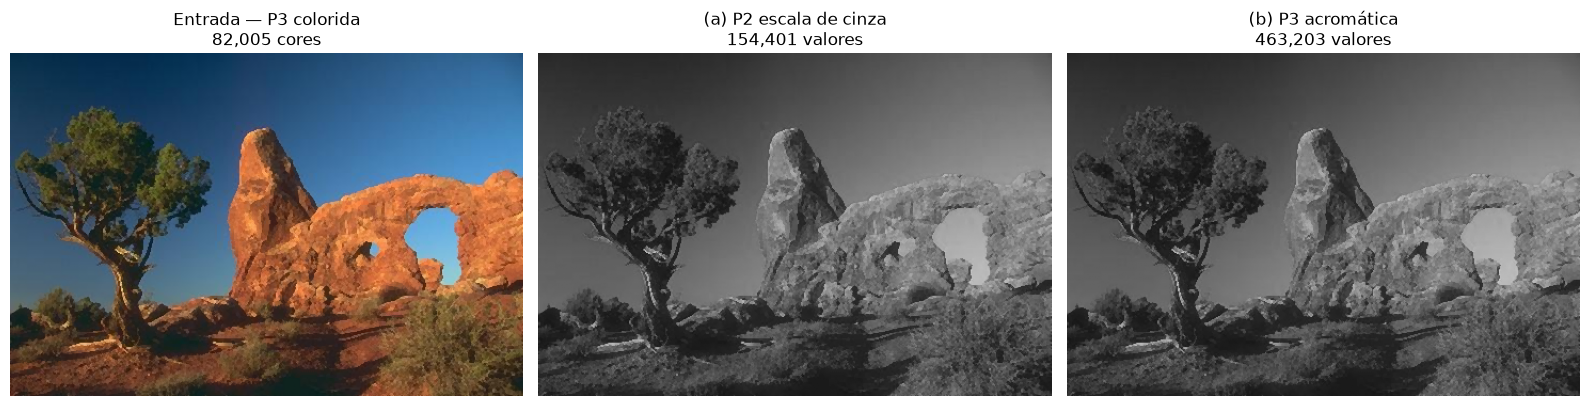

Os painéis (a) e (b) são visualmente indistinguíveis — como devem ser,
já que contêm os mesmos valores. O primeiro foi renderizado a partir de
um único canal; o segundo, a partir de três canais idênticos.


In [21]:
# --- Painel final ---

fig, eixos = plt.subplots(1, 3, figsize=(16, 5))

eixos[0].imshow(rgb / MAXVAL)
eixos[0].set_title(f"Entrada — P3 colorida\n{cores_distintas:,} cores")

eixos[1].imshow(a_disco, cmap="gray", vmin=0, vmax=MAXVAL)
eixos[1].set_title(f"(a) P2 escala de cinza\n{cinza.size:,} valores")

eixos[2].imshow(b_disco / MAXVAL)
eixos[2].set_title(f"(b) P3 acromática\n{cinza_rgb.size:,} valores")

for ax in eixos:
    ax.axis("off")
plt.tight_layout()
plt.show()

print("Os painéis (a) e (b) são visualmente indistinguíveis — como devem ser,")
print("já que contêm os mesmos valores. O primeiro foi renderizado a partir de")
print("um único canal; o segundo, a partir de três canais idênticos.")

## 3. Discussão: média aritmética não é luminância percebida

A média trata os três canais como igualmente importantes. O sistema visual
humano não funciona assim.

Os próprios slides da disciplina registram que a visão é dominada pelos sinais
de intensidade luminosa, e que a informação de cor é "menos bem definida" e
integrada posteriormente pelo cérebro. A apostila desenvolve o ponto ao tratar
do formato JFIF: a visão humana "é muito mais sensível à quantidade de luz (a
luminância) do que à cor (a cromaticidade)", e é justamente essa assimetria que
o modelo YCbCr explora para comprimir imagens.

Dentro do próprio espectro visível, a sensibilidade também é desigual: o verde
contribui muito mais para a sensação de claridade que o azul. A recomendação
BT.601 quantifica isso:

    luma = 0,299·R + 0,587·G + 0,114·B

Comparada à média, que atribui 0,333 a cada canal, a diferença é grande: o verde
pesa quase o dobro, e o azul menos de um terço.

### O que isso significa para esta atividade

O enunciado pede a média, e a média é o resultado entregue. A comparação abaixo
serve para dimensionar a diferença entre as duas formulações e entender **quando**
ela importa: a média é adequada quando se quer tratar os canais simetricamente —
por exemplo, ao analisar dados de sensores sem relação com percepção visual. A
ponderação por luminância é preferível quando o objetivo é que o resultado
*pareça* ter o mesmo brilho da imagem colorida para um observador humano.

Método                         Média    Desvio    Mín    Máx
------------------------------------------------------------
Média aritmética (1/3)         85.04     35.95     18    203
Luminância BT.601              84.84     36.36     20    209

Diferença média  : 5.65 níveis
Diferença máxima : 15 níveis
Píxeis idênticos : 3.68%


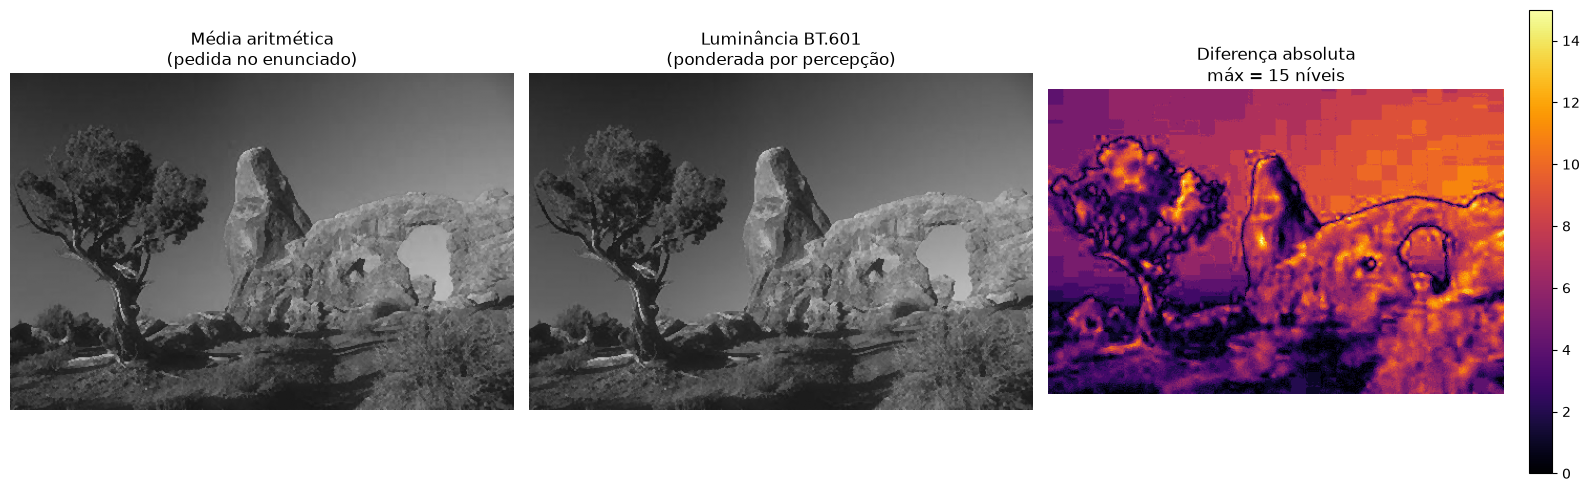

As maiores diferenças concentram-se onde um canal domina — regiões
fortemente azuladas ficam mais escuras sob BT.601, e regiões esverdeadas
mais claras, refletindo os pesos de cada componente.


In [22]:
# --- Comparação: média aritmética × luminância BT.601 ---

PESOS_BT601 = np.array([0.299, 0.587, 0.114])

luminancia = np.rint(rgb @ PESOS_BT601).astype(np.int32)
diferenca = np.abs(cinza - luminancia)

print(f"{'Método':<26}{'Média':>10}{'Desvio':>10}{'Mín':>7}{'Máx':>7}")
print("-" * 60)
print(f"{'Média aritmética (1/3)':<26}{cinza.mean():>10.2f}"
      f"{cinza.std():>10.2f}{cinza.min():>7}{cinza.max():>7}")
print(f"{'Luminância BT.601':<26}{luminancia.mean():>10.2f}"
      f"{luminancia.std():>10.2f}{luminancia.min():>7}{luminancia.max():>7}")
print()
print(f"Diferença média  : {diferenca.mean():.2f} níveis")
print(f"Diferença máxima : {diferenca.max()} níveis")
print(f"Píxeis idênticos : {(diferenca == 0).mean() * 100:.2f}%")

fig, eixos = plt.subplots(1, 3, figsize=(16, 5))
eixos[0].imshow(cinza, cmap="gray", vmin=0, vmax=MAXVAL)
eixos[0].set_title("Média aritmética\n(pedida no enunciado)")
eixos[1].imshow(luminancia, cmap="gray", vmin=0, vmax=MAXVAL)
eixos[1].set_title("Luminância BT.601\n(ponderada por percepção)")
im = eixos[2].imshow(diferenca, cmap="inferno")
eixos[2].set_title(f"Diferença absoluta\nmáx = {diferenca.max()} níveis")
fig.colorbar(im, ax=eixos[2], fraction=0.046)
for ax in eixos:
    ax.axis("off")
plt.tight_layout()
plt.show()

print("As maiores diferenças concentram-se onde um canal domina — regiões")
print("fortemente azuladas ficam mais escuras sob BT.601, e regiões esverdeadas")
print("mais claras, refletindo os pesos de cada componente.")

Cor RGB                Média
------------------------------
[255, 0, 0]               85
[0, 255, 0]               85
[0, 0, 255]               85
[85, 85, 85]              85
[170, 85, 0]              85

Todas produzem o mesmo cinza. Nenhuma operação posterior consegue
distingui-las: três valores independentes foram reduzidos a um, e as
infinitas combinações de mesma soma tornaram-se equivalentes.


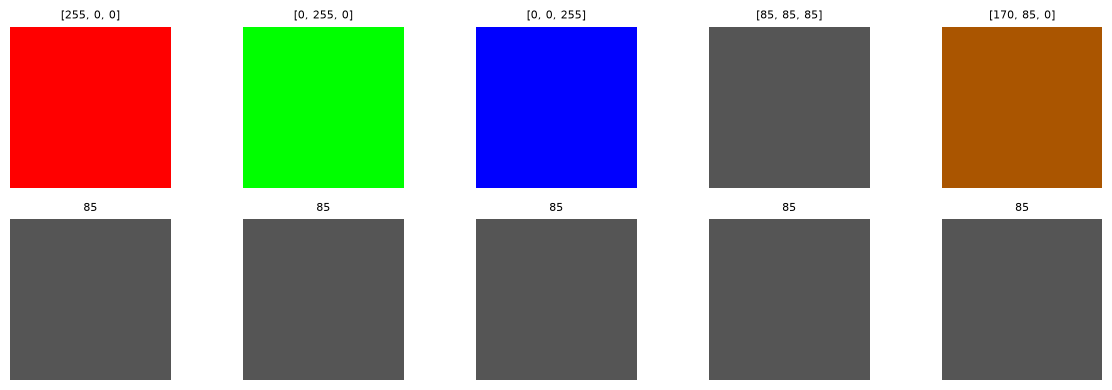

In [23]:
# --- Bônus: a perda de informação é irreversível ---

# Cores muito diferentes que produzem exatamente o mesmo cinza
exemplos = np.array([
    [255,   0,   0],   # vermelho puro
    [  0, 255,   0],   # verde puro
    [  0,   0, 255],   # azul puro
    [ 85,  85,  85],   # cinza
    [170,  85,   0],   # laranja escuro
])

print(f"{'Cor RGB':<20}{'Média':>8}")
print("-" * 30)
for cor in exemplos:
    print(f"{str(cor.tolist()):<20}{cor.mean():>8.0f}")

print()
print("Todas produzem o mesmo cinza. Nenhuma operação posterior consegue")
print("distingui-las: três valores independentes foram reduzidos a um, e as")
print("infinitas combinações de mesma soma tornaram-se equivalentes.")

fig, eixos = plt.subplots(2, len(exemplos), figsize=(12, 4))
for j, cor in enumerate(exemplos):
    eixos[0, j].imshow(np.tile(cor / MAXVAL, (10, 10, 1)))
    eixos[0, j].set_title(str(cor.tolist()), fontsize=8)
    eixos[1, j].imshow(np.full((10, 10), cor.mean()),
                       cmap="gray", vmin=0, vmax=MAXVAL)
    eixos[1, j].set_title(f"{cor.mean():.0f}", fontsize=8)
    for i in range(2):
        eixos[i, j].axis("off")
plt.tight_layout()
plt.show()

---

## Conclusões

### Arquivos gerados

| Item | Arquivo | Formato | Valores |
|------|---------|---------|---------|
| (a) | `a_Fig4_media_P2.pgm` | PGM P2 | 1 por píxel |
| (b) | `b_Fig4_media_P3.ppm` | PPM P3 | 3 por píxel |

Ambos validados por round-trip, com magic number e `maxval` conferidos e nenhuma
linha excedendo 70 caracteres.

### A relação entre os dois itens

Os dois arquivos carregam informação **idêntica** — a verificação comparou cada
canal do item (b) com o item (a), lidos do disco, e todos coincidem. O item (b)
replica cada valor três vezes e ocupa cerca do triplo do espaço sem acrescentar
nada.

Isso não torna o item (b) inútil: gravar em PPM mantém a imagem compatível com
pipelines que esperam três canais, permitindo reintroduzir cor em etapas
seguintes. Mas é importante reconhecer que, do ponto de vista de informação, o
arquivo é redundante por construção.

### A perda na conversão

Reduzir três componentes a uma é irreversível. Cores muito distintas — vermelho
puro, verde puro, um cinza médio — colapsam no mesmo valor, e nenhuma operação
posterior as separa. É a mesma natureza de perda das atividades de quantização e
binarização, mas atuando sobre a **dimensionalidade** do píxel em vez de sobre a
sua profundidade.

### Média × luminância

A média atribui peso igual aos três canais, o que não corresponde à
sensibilidade da visão humana. A ponderação BT.601 dá ao verde quase o dobro do
peso e ao azul menos de um terço, refletindo o que os slides descrevem sobre a
predominância do sinal de luminosidade e o que a apostila detalha ao tratar do
modelo YCbCr.

A diferença entre as duas formulações é mensurável nesta imagem, e concentra-se
nas regiões onde um canal domina. Nenhuma das duas é "correta" em absoluto: a
média é adequada quando se quer simetria entre os canais, a luminância quando o
critério é a aparência para um observador humano.